In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from matplotlib import pyplot as plt
import numpy as np, pandas as pd
import os
from collections import Counter
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [28]:
# _______________Globals__________________
feature_names = list()
for index in range(1, 6):
    feature_names.extend(["Suit"+str(index), "Rank"+str(index)])

feature_names.append('class')

training_input_file = os.path.abspath(r"C:\Users\Dell precision 5560\Project/Data/train.csv")
testing_input_file = os.path.abspath(r"C:\Users\Dell precision 5560\Project/Data/test.csv")


In [29]:
#____________Raw_data____________
train_data = pd.read_csv(training_input_file, names =  feature_names)
test_data = pd.read_csv(testing_input_file, names = feature_names)

# Shuffle training data
train_data = train_data.sample(frac = 1).reset_index(drop = True)

# Seperate data and classes
train_x = train_data.drop('class', axis = 1)
train_y = train_data['class']

test_x = test_data.drop('class', axis = 1)
test_y = test_data['class']

print("Instances in training data :", train_data.shape)
print("Instances in testing data  :", test_data.shape)

Instances in training data : (25010, 11)
Instances in testing data  : (1000000, 11)


In [30]:
# ____________Using default setting_______________

rf = RandomForestClassifier()
rf.fit(train_x, train_y)

prediction = rf.predict(test_x)
accuracy = accuracy_score(test_y, prediction)

print("\nAccuracy using default Random Forest Model :", round(accuracy * 100, 3),"%\n",)


# ____________Feature Importance__________________
importance = pd.DataFrame({
    'Feature': train_x.columns,
    'Importance': rf.feature_importances_ * 100
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

# Confusion_matrix

cm = confusion_matrix(test_y, prediction)

cm_display = pd.DataFrame(
    cm,
    index=[f"Real {i}" for i in range(10)],
    columns=[f"Pred {i}" for i in range(10)] 
)

display(cm_display)



Accuracy using default Random Forest Model : 61.478 %

  Feature  Importance
1   Rank1   13.705323
9   Rank5   13.543903
7   Rank4   13.185484
3   Rank2   13.112192
5   Rank3   13.026950
6   Suit4    6.832724
4   Suit3    6.808785
0   Suit1    6.675199
2   Suit2    6.653590
8   Suit5    6.455851


,Pred 0,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5,Pred 6,Pred 7,Pred 8,Pred 9
Real 0,404179,97015,11,2,1,0,0,0,0,1
Real 1,211924,210332,209,27,6,0,0,0,0,0
Real 2,11986,35418,203,13,0,0,2,0,0,0
Real 3,3447,17574,48,52,0,0,0,0,0,0
Real 4,367,3510,4,0,4,0,0,0,0,0
Real 5,1812,177,0,0,0,7,0,0,0,0
Real 6,62,1332,24,6,0,0,0,0,0,0
Real 7,3,215,8,4,0,0,0,0,0,0
Real 8,2,10,0,0,0,0,0,0,0,0
Real 9,2,1,0,0,0,0,0,0,0,0


In [31]:
# ______________Tunning Model____________
rf_t = RandomForestClassifier(
    n_estimators = 500,
    max_depth = None,
    class_weight = 'balanced',
    random_state = 40,
    max_features = None,
    n_jobs = -1, 
    min_samples_leaf = 2
)

rf_t.fit(train_x, train_y)

prediction_t = rf_t.predict(test_x)
accuracy_t = accuracy_score(test_y, prediction_t)

print("\nAccuracy using tunning Random Forest Model :", round(accuracy_t * 100, 3),"%\n",)

# Confusion Matrix
cm_t = confusion_matrix(test_y, prediction_t )

cm_t_display = pd.DataFrame(
    cm_t,
    index=[f"Real {i}" for i in range(10)],
    columns=[f"Pred {i}" for i in range(10)] 
)

display(cm_t_display)


Accuracy using tunning Random Forest Model : 63.354 %



,Pred 0,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5,Pred 6,Pred 7,Pred 8,Pred 9
Real 0,406236,94920,43,4,3,3,0,0,0,0
Real 1,195737,225473,1050,119,59,1,3,5,26,25
Real 2,9850,36944,717,86,13,0,8,1,2,1
Real 3,2903,17493,138,565,4,0,11,2,2,3
Real 4,192,3634,22,3,13,0,0,0,8,13
Real 5,1322,143,0,0,0,529,0,0,1,1
Real 6,53,1250,65,52,1,0,3,0,0,0
Real 7,0,194,6,30,0,0,0,0,0,0
Real 8,0,6,0,0,0,6,0,0,0,0
Real 9,1,1,0,0,0,1,0,0,0,0


In [32]:
# ____________Feature Engineering_________
def features(row):
    suits = [ 
        row['Suit1'],
        row['Suit2'],
        row['Suit3'],
        row['Suit4'],
        row['Suit5'] 
    ]
    ranks = [ 
        row['Rank1'],
        row['Rank2'],
        row['Rank3'],
        row['Rank4'],
        row['Rank5']
    ]

    # Rank statistics

    r_count = Counter(ranks)

    unique_rank = len(r_count)

    max_same = max(r_count.values())

    count_pair = sum( 1 for v in r_count.values() if v == 2)

    has_three = int( 3 in r_count.values())

    # Flush
    is_flush = int( len(set(suits)) == 1)

    # Straight
    r_sorted = sorted(ranks)
    is_straight = int( all(r_sorted[i] + 1 == r_sorted[i+1] for i in range(4)))

    return pd.Series({
        'unique_rank_count': unique_rank,

        'max_same_rank': max_same,

        'count_pair': count_pair,

        'has_three_kind': has_three,

        'is_straight': is_straight,

        'is_flush' : is_flush
     })
    
def add_feature(d):
    d = d.copy()

    new_f = d.apply(features, axis = 1)
    d = pd.concat([d, new_f], axis = 1)

    return d


Instances in training data : (25010, 17)
Instances in testing data  : (1000000, 17)

Accuracy using Random Forest Classifier : 99.961 %



,Pred 0,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5,Pred 6,Pred 7,Pred 8,Pred 9
Real 0,501209,0,0,0,0,0,0,0,0,0
Real 1,0,422498,0,0,0,0,0,0,0,0
Real 2,0,0,47622,0,0,0,0,0,0,0
Real 3,0,0,0,21121,0,0,0,0,0,0
Real 4,383,0,0,0,3502,0,0,0,0,0
Real 5,0,0,0,0,0,1995,0,0,0,1
Real 6,0,0,0,0,0,0,1424,0,0,0
Real 7,0,0,0,0,0,0,0,230,0,0
Real 8,0,0,0,0,0,0,0,0,12,0
Real 9,0,0,0,0,0,3,0,0,0,0


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    501209
           1       1.00      1.00      1.00    422498
           2       1.00      1.00      1.00     47622
           3       1.00      1.00      1.00     21121
           4       1.00      0.90      0.95      3885
           5       1.00      1.00      1.00      1996
           6       1.00      1.00      1.00      1424
           7       1.00      1.00      1.00       230
           8       1.00      1.00      1.00        12
           9       0.00      0.00      0.00         3

    accuracy                           1.00   1000000
   macro avg       0.90      0.89      0.89   1000000
weighted avg       1.00      1.00      1.00   1000000

              Feature  Importance
10  unique_rank_count   36.888204
11      max_same_rank   31.748047
12         count_pair   26.013504
13     has_three_kind    3.072961
14        is_straight    1.048342
15           is_flush    0.723962
1  

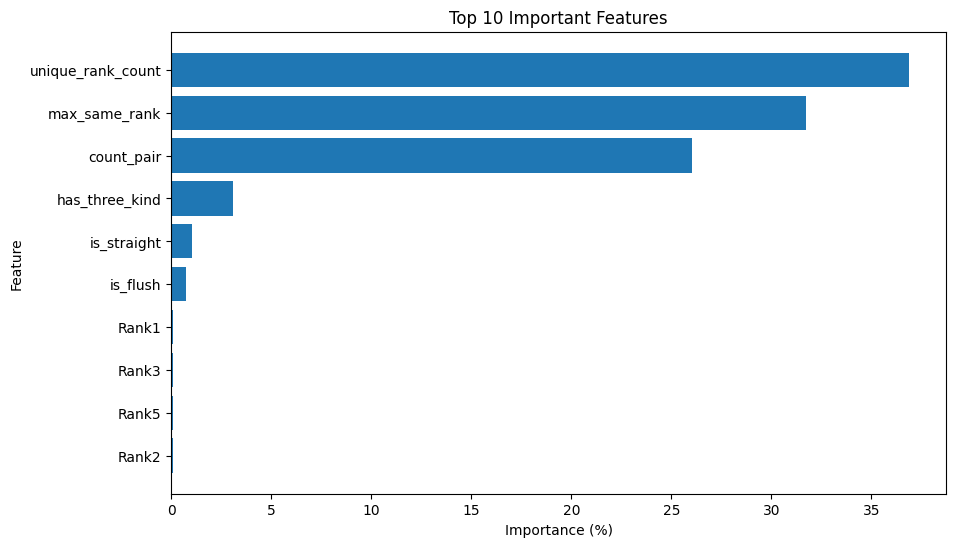

In [33]:
#____________RandomForest using Feature Engineering____________

# Add feature to original data
train_data_f = add_feature(train_data)
test_data_f = add_feature(test_data)

# Seperate data and classes
train_x_f = train_data_f.drop('class', axis=1)
train_y_f = train_data_f['class']

test_x_f = test_data_f.drop('class', axis=1)
test_y_f = test_data_f['class']

print("Instances in training data :", train_data_f.shape)
print("Instances in testing data  :", test_data_f.shape)

# Train model
RF_f = RandomForestClassifier(class_weight = 'balanced' )
RF_f.fit(train_x_f, train_y_f)

prediction_f = RF_f.predict(test_x_f)
accuracy_f = accuracy_score(test_y_f, prediction_f)

print("\nAccuracy using Random Forest Classifier :", round(accuracy_f * 100, 3),"%\n")



#____________Confusion Matrix_____________
cm_f = confusion_matrix(test_y_f, prediction_f )

cm_f_display = pd.DataFrame(
    cm_f,
    index=[f"Real {i}" for i in range(10)],
    columns=[f"Pred {i}" for i in range(10)] 
)

display(cm_f_display)

print(classification_report(test_y_f, prediction_f))


#_____________Feature Importance_______________
importance_f = pd.DataFrame({
    'Feature': train_x_f.columns,
    'Importance': RF_f.feature_importances_ * 100
})

importance_f = importance_f.sort_values(
    by='Importance',
    ascending=False
)

print(importance_f)


# ____________Top Feature graph__________
importance_f = importance_f.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    importance_f['Feature'].tail(10),
    importance_f['Importance'].tail(10)
)

plt.xlabel('Importance (%)')
plt.ylabel('Feature')
plt.title('Top 10 Important Features')

plt.show()

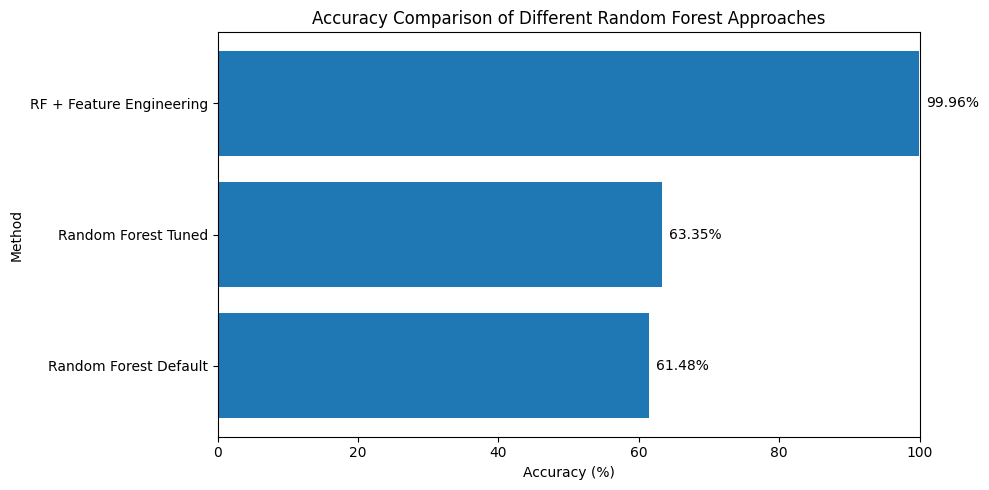

In [34]:
import matplotlib.pyplot as plt

methods = [
    "Random Forest Default",
    "Random Forest Tuned",
    "RF + Feature Engineering"
]

accuracies = [accuracy * 100, accuracy_t * 100 , accuracy_f * 100]

plt.figure(figsize = (10, 5))
bars = plt.barh(methods, accuracies)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}%",
        va='center'
    )

plt.xlabel("Accuracy (%)")
plt.ylabel("Method")
plt.title("Accuracy Comparison of Different Random Forest Approaches")

plt.xlim(0, 100)

plt.tight_layout()
plt.show()